# IO


## Save SciTiff Image

`scitiff.io.save_scitiff` function can save either a 2-5 dimensional image(`scipp.DataArray`) or the container of the image(`scipp.DataGroup`) with high-level/extra metadata.<br>
See [Scitiff Metadata Schema](../index.md#scitiff-metadata-schema) for details.<br>

> The image or the container is validated if it matches the schema or the convention.

### Save `scipp.DataArray` as Scitiff Image 
The image(`scipp.DataArray`) should have `x`, `y`, `z`, `t`, `c` dimensions (all dimensions are optional).<br>
The order of the dimension is automatically corrected <br>
if it does not follow the conventional order, <br>
[`x`, `y`, `c`, `z`, `t`] (from the innermost dimension to the outermost dimension).

In [1]:
from scitiff.data import hyperstack_example
import scipp as sc

sample_img = hyperstack_example()
sample_img

<scipp.DataArray>
Dimensions: Sizes[c:3, t:4, z:2, y:300, x:400, ]
Coordinates:
* c                          string        <no unit>  (c)  ["R", "G", "B"]
* t                           int64              [s]  (t)  [0, 1, 2, 3]
* x                         float64             [mm]  (x)  [0, 1.00251, ..., 398.997, 400]
* y                         float64             [mm]  (y)  [0, 1.00334, ..., 298.997, 300]
* z                           int64             [mm]  (z)  [10, 20]
Data:
                            float32         [counts]  (c, t, z, y, x)  [0, 1, ..., 89998, 89999]

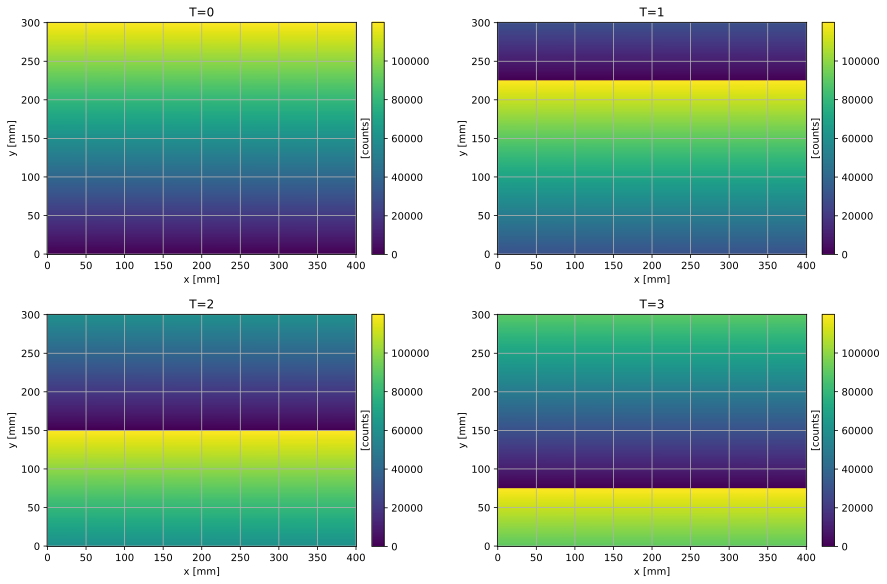

In [2]:
config = {"grid": True, "aspect": True}
img = sample_img.mean('c').mean('z')
(img['t', 0].plot(title='T=0', **config) + img['t', 1].plot(title='T=1', **config)) / (
    img['t', 2].plot(title='T=2', **config) + img['t', 3].plot(title='T=3', **config)
)

In [3]:
from scitiff.io import save_scitiff

save_scitiff(sample_img, 'sample_img.tiff')

## Load SciTIFF Image as a `scipp.DataArray`

`scitiff.io.load_scitiff` wraps the image as a `scipp.DataArray`.<br>
It also adds coordinates and masks using the `scitiffmetadata` in the `tiff` file.<br>

In [4]:
from scitiff.io import load_scitiff

loaded_scitiff: sc.DataArray = load_scitiff('sample_img.tiff', only_image=True)
loaded_scitiff

<scipp.DataArray>
Dimensions: Sizes[t:4, z:2, c:3, y:300, x:400, ]
Coordinates:
* c                          string        <no unit>  (c)  ["R", "G", "B"]
* t                           int64              [s]  (t)  [0, 1, 2, 3]
* x                         float64             [mm]  (x)  [0, 1.00251, ..., 398.997, 400]
* y                         float64             [mm]  (y)  [0, 1.00334, ..., 298.997, 300]
* z                           int64             [mm]  (z)  [10, 20]
Data:
                            float32         [counts]  (t, z, c, y, x)  [0, 1, ..., 89998, 89999]

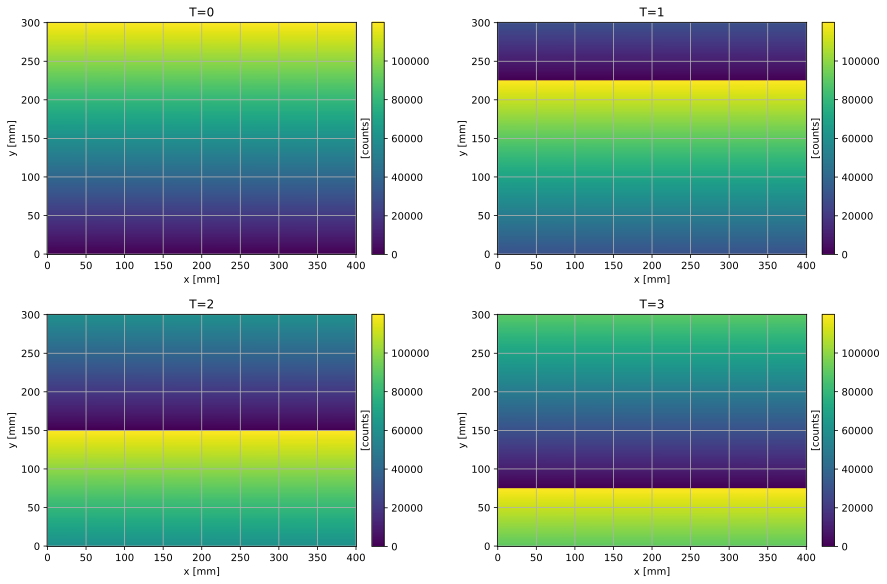

In [5]:
config = {"grid": True, "aspect": True}
loaded_img = loaded_scitiff.mean('c').mean('z')
(
    loaded_img['t', 0].plot(title='T=0', **config)
    + loaded_img['t', 1].plot(title='T=1', **config)
) / (
    loaded_img['t', 2].plot(title='T=2', **config)
    + loaded_img['t', 3].plot(title='T=3', **config)
)

## Save `scipp.DataGroup` with High-Level/Extra Meta Data as a SciTiff Image

The `scipp.DataGroup` should have `image` field which is the `image` as a `scipp.DataArray`.

There is `extra` field that user can save arbitrary metadata as a dictionary.<br>
Scitiff IO module only supports `string`, `int`, `float` and a **scalar** `scipp.Variable` as extra meata values.<br>
The `extra` field should be either a `dict` or a `DataGroup` so that the IO module can save it.

In [6]:
from scitiff import DAQMetadata

sample_image_dg = sc.DataGroup(
    image=sample_img,  # Image must be set with the key, 'image'.
    daq=DAQMetadata(facility='ESS-DMSC', instrument='SW'),
    extra=sc.DataGroup(
        {'written-at': sc.datetime('now', unit='s'), 'writer': 'RapBear', 'some-number': 1}
    ),
)
display(sample_image_dg)
display('Extra Metadata', sample_image_dg['extra'])

DataGroup(sizes={'c': 3, 't': 4, 'z': 2, 'y': 300, 'x': 400}, keys=[
    image: DataArray({'c': 3, 't': 4, 'z': 2, 'y': 300, 'x': 400}),
    daq: facility='ESS-DMSC' instrument='SW' detector_type='Unknown' source_type='Unknown' source=None simulated=None,
    extra: DataGroup(3, {}),
])

'Extra Metadata'

DataGroup(sizes={}, keys=[
    written-at: Variable({}),
    writer: RapBear,
    some-number: 1,
])

In [7]:
from scitiff.io import save_scitiff

# Save the data group and it will save the metadata with it.
save_scitiff(sample_image_dg, 'sample_img_with_extra_metadata.tiff')

## Load SciTIFF Image with High-Level/Extra Metadata as a `scipp.DataGroup`

By default, `load_scitiff` loads the high-level and extra metadata as a `scipp.DataGroup`.

In [8]:
from scitiff.io import load_scitiff

loaded_scitiff: sc.DataGroup = load_scitiff('sample_img_with_extra_metadata.tiff')
loaded_scitiff

DataGroup(sizes={'t': 4, 'z': 2, 'c': 3, 'y': 300, 'x': 400}, keys=[
    image: DataArray({'t': 4, 'z': 2, 'c': 3, 'y': 300, 'x': 400}),
    daq: facility='ESS-DMSC' instrument='SW' detector_type='Unknown' source_type='Unknown' source=None simulated=None,
    extra: {'written-at': <scipp.Variable> ()  datetime64              [s]  2026-06-23T09:11:26, 'writer': 'RapBear', 'some-number': 1},
    schema_version: 26.6.0,
])

## Show Metadata Only

In [9]:
from scitiff.executables import show_metadata

show_metadata('sample_img.tiff')

{
    'scitiffmeta': {
        'image': {
            'data': {'unit': 'counts', 'dtype': 'float32', 'dims': [...], 'shape': [...]},
            'masks': {},
            'coords': {'c': {...}, 't': {...}, 'z': {...}, 'y': {...}, 'x': {...}},
            'name': None
        },
        'daq': {
            'facility': 'Unknown',
            'instrument': 'Unknown',
            'detector_type': 'Unknown',
            'source_type': 'Unknown',
            'source': None,
            'simulated': None
        },
        'extra': None,
        'schema_version': '26.6.0'
    }
}

## Load Non-Scitiff Images

Sometimes you might want to load tiff images that are not compatible with scitiff.<br>
i.e. no metadata, incompatible dtype, or broken metadata with wrong fields or values.

`load_scitiff` will try to load metadata and handle incompatible profiles,<br>
but if it is not possible it will load the tiff image as it is and wrap it into scipp data structure.

.. note::
    `load_scitiff` will throw warning if it fails to load the file as expected way
    so please pay attention to the warning messages.

/tmp/ipykernel_2707/3829974585.py:4: ImageJMetadataNotFoundWarning: ImageJ metadata not found in the tiff file.
Loading the image with arbitrary dimensions...

  no_meta_loaded_image = load_scitiff('no-meta.tiff')['image']


<scipp.DataArray>
Dimensions: Sizes[dim_0:3, dim_1:4, dim_2:2, dim_3:300, dim_4:400, ]
Data:
                            float32  [dimensionless]  (dim_0, dim_1, dim_2, dim_3, dim_4)  [0, 1, ..., 89998, 89999]

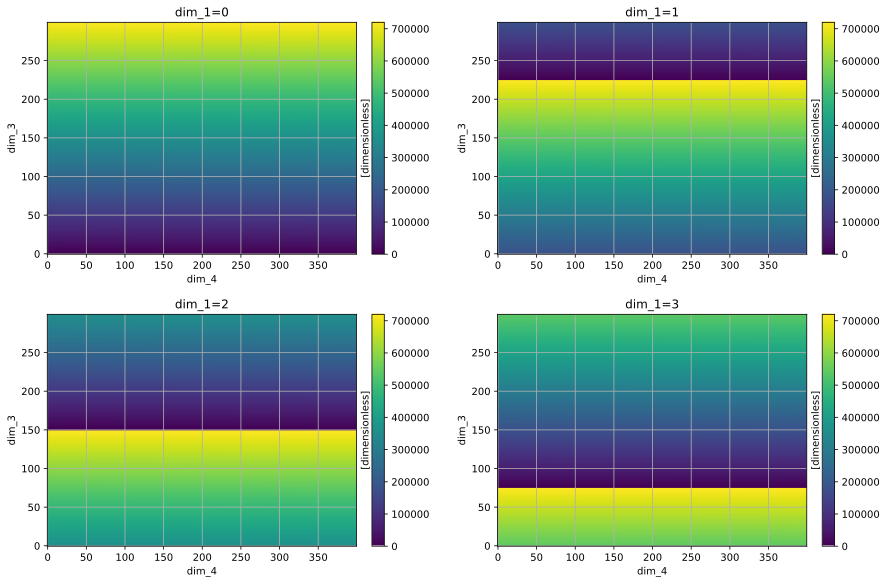

In [10]:
import tifffile as tf

tf.imwrite('no-meta.tiff', data=sample_img.values)
no_meta_loaded_image = load_scitiff('no-meta.tiff')['image']
display(no_meta_loaded_image)
no_meta_loaded_image_reduced = no_meta_loaded_image.sum('dim_0').sum('dim_2')
(
    no_meta_loaded_image_reduced['dim_1', 0].plot(title='dim_1=0', **config)
    + no_meta_loaded_image_reduced['dim_1', 1].plot(title='dim_1=1', **config)
) / (
    no_meta_loaded_image_reduced['dim_1', 2].plot(title='dim_1=2', **config)
    + no_meta_loaded_image_reduced['dim_1', 3].plot(title='dim_1=3', **config)
)

.. tip::
    You can rename the dimensions and use it just like other scitiff images.<br>
    Do it only if you know which `dim_{i}` corresponds to which of ('t', 'z', 'c', 'y', 'x').

<scipp.DataArray>
Dimensions: Sizes[c:3, t:4, z:2, y:300, x:400, ]
Data:
                            float32  [dimensionless]  (c, t, z, y, x)  [0, 1, ..., 89998, 89999]

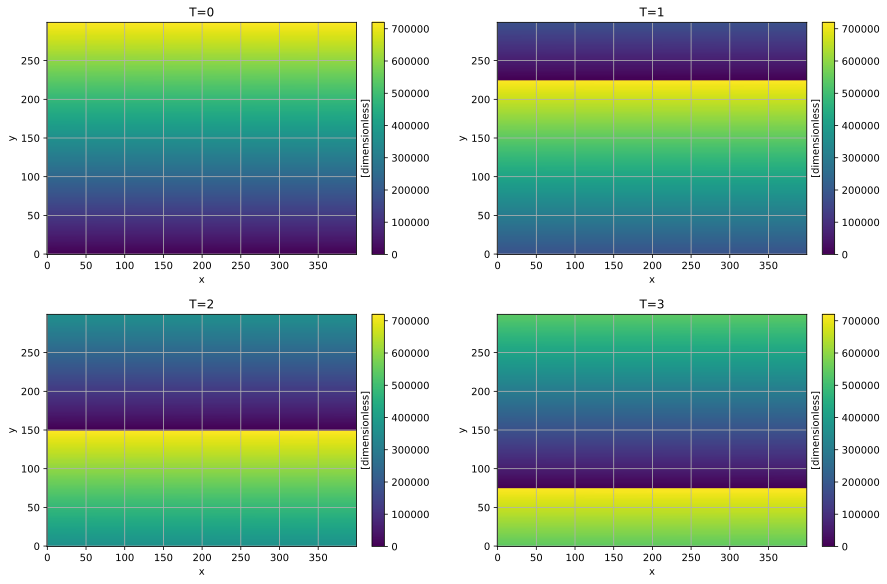

In [11]:
renamed_image = no_meta_loaded_image.rename_dims(
    {"dim_0": "c", "dim_1": "t", "dim_2": "z", "dim_3": "y", "dim_4": "x"}
)
display(renamed_image)
renamed_image_reduced = renamed_image.sum('z').sum('c')
(
    renamed_image_reduced['t', 0].plot(title='T=0', **config)
    + renamed_image_reduced['t', 1].plot(title='T=1', **config)
) / (
    renamed_image_reduced['t', 2].plot(title='T=2', **config)
    + renamed_image_reduced['t', 3].plot(title='T=3', **config)
)

## Mask and Standard Deviation

.. attention:: This is not officially declared in the scitiff-schema.

In some cases, users need to save variances and masks into the file along with the counts.

For example, a simulated image is normalized with a background image with some 0 counts pixels.<br>
Then the variances are not simply same as the counts and 0 counts pixels of background image should be masked.

It is not practical to save such information in the plain text json.

Therefore `scitiff.io` has helpers to save/load `mask` and `variances` as channels.

.. tip:: If masks can be represented as 1 dimensional array, it is better to keep it as masks.


Here is the sample image we want to save and load.<br>
The image stack has 4 dimensions, (t, x, y, z) data, a mask with same dimension and variances.<br>
If we save it as it is, the mask is not accepted as it is not 1 dimensional array<br>
and the variances will be simply ignored.

<scipp.DataArray>
Dimensions: Sizes[t:4, z:2, y:300, x:400, ]
Coordinates:
* t                           int64              [s]  (t)  [0, 1, 2, 3]
* x                         float64             [mm]  (x)  [0, 1.00251, ..., 398.997, 400]
* y                         float64             [mm]  (y)  [0, 1.00334, ..., 298.997, 300]
* z                           int64             [mm]  (z)  [10, 20]
Data:
                            float32         [counts]  (t, z, y, x)  [0, 1, ..., 89998, 89999]  [0, 0.1, ..., 8999.8, 8999.9]
Masks:
  mask                         bool        <no unit>  (t, z, y, x)  [True, False, ..., False, False]

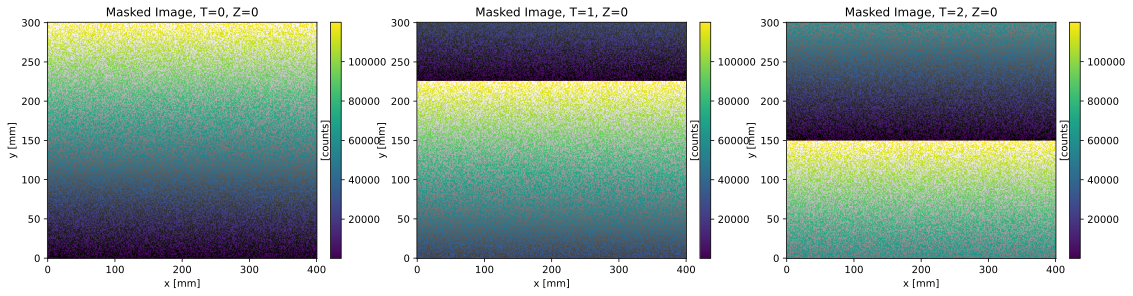

In [12]:
from scitiff.data import hyperstack_example_with_variances_and_mask

sample_img_with_stdev_and_mask = hyperstack_example_with_variances_and_mask()
display(sample_img_with_stdev_and_mask)
(
    sample_img_with_stdev_and_mask['t', 0]['z', 0].plot(title="Masked Image, T=0, Z=0")
    + sample_img_with_stdev_and_mask['t', 1]['z', 0].plot(
        title="Masked Image, T=1, Z=0"
    )
    + sample_img_with_stdev_and_mask['t', 2]['z', 0].plot(
        title="Masked Image, T=2, Z=0"
    )
)

### Save Mask and Standard Deviation

In order to save the mask and the variances,

you can simply set `concat_stdevs_and_mask` argument to `True` of `save_scitiff`.

Then it will concatenate stdevs and mask into channel dimension before it saves the image.

In [13]:
from scitiff.io import save_scitiff

save_scitiff(
    sample_img_with_stdev_and_mask,
    'sample_img_with_stdev_and_mask.tiff',
    concat_stdevs_and_mask=True,
    mask_name='mask',
)

Or you can manually translate the image to have stdevs and mask concatenated into channel dimension.

Note that the `c` (channel) coordinate has `string` values that indicates which channel is `intensities`, `stdevs` or `mask`.

And you can save the object as it is.

In [14]:
from scitiff.io import save_scitiff
from scitiff.io import to_scitiff_image

da = to_scitiff_image(
    sample_img_with_stdev_and_mask, concat_stdevs_and_mask=True, mask_name='mask'
)
display(da)
save_scitiff(da, 'sample_img_with_stdev_and_mask.tiff', concat_stdevs_and_mask=False)

<scipp.DataArray>
Dimensions: Sizes[t:4, z:2, c:3, y:300, x:400, ]
Coordinates:
* c                          string        <no unit>  (c)  ["intensities", "stdevs", "mask"]
* t                           int64              [s]  (t)  [0, 1, 2, 3]
* x                         float64             [mm]  (x)  [0, 1.00251, ..., 398.997, 400]
* y                         float64             [mm]  (y)  [0, 1.00334, ..., 298.997, 300]
* z                           int64             [mm]  (z)  [10, 20]
Data:
                            float32         [counts]  (t, z, c, y, x)  [0, 1, ..., 0, 0]

### Load Mask and Standard Deviation

As the `stdevs` and `mask` is saved into the tiff stack, you can load them as well.

<scipp.DataArray>
Dimensions: Sizes[t:4, z:2, c:3, y:300, x:400, ]
Coordinates:
* c                          string        <no unit>  (c)  ["intensities", "stdevs", "mask"]
* t                           int64              [s]  (t)  [0, 1, 2, 3]
* x                         float64             [mm]  (x)  [0, 1.00251, ..., 398.997, 400]
* y                         float64             [mm]  (y)  [0, 1.00334, ..., 298.997, 300]
* z                           int64             [mm]  (z)  [10, 20]
Data:
                            float32         [counts]  (t, z, c, y, x)  [0, 1, ..., 0, 0]

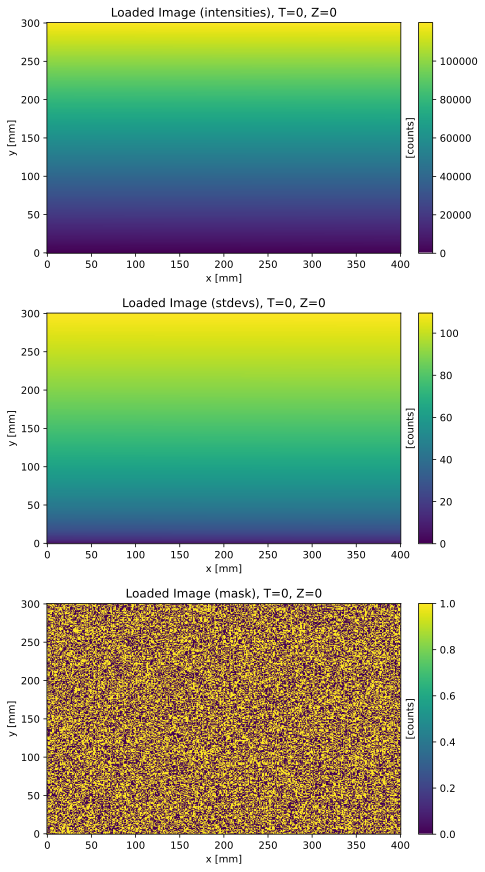

In [15]:
import scipp as sc
from scitiff.io import load_scitiff

img_with_stdev_and_mask_dg = load_scitiff(
    'sample_img_with_stdev_and_mask.tiff', resolve_channels=False
)
img_with_stdev_and_mask = img_with_stdev_and_mask_dg['image']
display(img_with_stdev_and_mask)
tiled = (
    img_with_stdev_and_mask['c', sc.scalar('intensities')]['t', 0]['z', 0].plot(
        title='Loaded Image (intensities), T=0, Z=0'
    )
    / img_with_stdev_and_mask['c', sc.scalar('stdevs')]['t', 0]['z', 0].plot(
        title='Loaded Image (stdevs), T=0, Z=0'
    )
    / img_with_stdev_and_mask['c', sc.scalar('mask')]['t', 0]['z', 0].plot(
        title='Loaded Image (mask), T=0, Z=0'
    )
)
tiled

There is a helper function that reassemble the data array with mask and variances from the loaded image.

<scipp.DataArray>
Dimensions: Sizes[t:4, z:2, y:300, x:400, ]
Coordinates:
  c                          string        <no unit>  ()  "intensities"
* t                           int64              [s]  (t)  [0, 1, 2, 3]
* x                         float64             [mm]  (x)  [0, 1.00251, ..., 398.997, 400]
* y                         float64             [mm]  (y)  [0, 1.00334, ..., 298.997, 300]
* z                           int64             [mm]  (z)  [10, 20]
Data:
                            float32         [counts]  (t, z, y, x)  [0, 1, ..., 89998, 89999]  [0, 0.1, ..., 8999.8, 8999.9]
Masks:
  scitiff-mask                 bool        <no unit>  (t, z, y, x)  [True, False, ..., False, False]

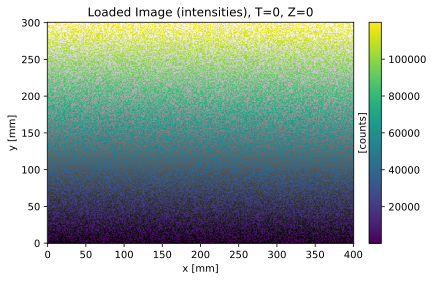

In [16]:
from scitiff.io import resolve_scitiff_channels

img_with_stdev_and_mask_resolved = resolve_scitiff_channels(img_with_stdev_and_mask)
display(img_with_stdev_and_mask_resolved)
img_with_stdev_and_mask_resolved['t', 0]['z', 0].plot(
    title='Loaded Image (intensities), T=0, Z=0'
)

Or you can simply set the `resolve_channels` argument to be `True`(default) and the loader will try reassembling the data array with mask and variances.

<scipp.DataArray>
Dimensions: Sizes[t:4, z:2, y:300, x:400, ]
Coordinates:
  c                          string        <no unit>  ()  "intensities"
* t                           int64              [s]  (t)  [0, 1, 2, 3]
* x                         float64             [mm]  (x)  [0, 1.00251, ..., 398.997, 400]
* y                         float64             [mm]  (y)  [0, 1.00334, ..., 298.997, 300]
* z                           int64             [mm]  (z)  [10, 20]
Data:
                            float32         [counts]  (t, z, y, x)  [0, 1, ..., 89998, 89999]  [0, 0.1, ..., 8999.8, 8999.9]
Masks:
  scitiff-mask                 bool        <no unit>  (t, z, y, x)  [True, False, ..., False, False]

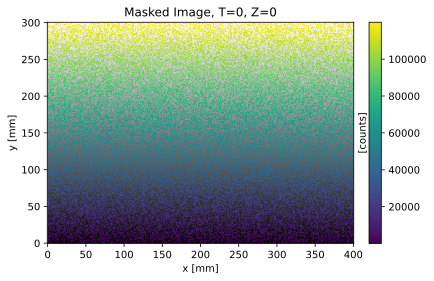

In [17]:
import scipp as sc
from scitiff.io import load_scitiff

img_with_stdev_and_mask_dg = load_scitiff(
    'sample_img_with_stdev_and_mask.tiff', resolve_channels=True
)
img_stdev_and_mask_resolved_at_once = img_with_stdev_and_mask_dg['image']

display(img_stdev_and_mask_resolved_at_once)
img_stdev_and_mask_resolved_at_once['t', 0]['z', 0].plot(title='Masked Image, T=0, Z=0')

# Backward Compatibility

`Scitiff` IO modules should be backward-compatible.<br>
Any files **written by** `scitiff` can be **read by a newer version** of `scitiff`.

On the other hand, `scitiff` may not be able to read an image <br>
if the image was **written by a newer version** of `scitiff`.<br>
i.e. a mandatory field became optional and was not included in the metadata.

Please tell us if you experience any errors in reading a `scitiff` image with a newer version of `scitiff python package`.